# GeoWatch Copilot — SegFormer Fine-tuning (Path B)

**Purpose:** Replace Path A tile-level CLIP classification with per-segment semantic segmentation using SegFormer + Clay v1 frozen encoder.

**Training data:** 5 cities × SAM annotations + OSM-derived road/drainage masks + sliding window patches
- Dharavi (Mumbai): 39 segments
- Nairobi (Kibera): 23 segments  
- Jakarta (North Jakarta): 28 segments
- HCMC (Ho Chi Minh City): 18 segments
- Kigali: 16 segments

**Architecture:**
- Encoder: Clay v1 frozen (768-dim embeddings, satellite-pretrained)
- Decoder: SegFormer MLP decoder (fine-tuned)
- Loss: CrossEntropy + Dice (handles class imbalance)
- Thresholding: CAAT dynamic per-class thresholds

**Output:** `segformer_geowatch.pth` — drop into pipeline.py replacing classify_tile()

---
**Runtime:** T4 GPU recommended. Set Runtime → Change runtime type → GPU before running.

## 0. Install dependencies

In [1]:
!pip install -q transformers timm einops geopandas shapely scipy pillow matplotlib seaborn
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu118
!pip install -q huggingface_hub

# Clay v1 encoder
!pip install -q git+https://github.com/Clay-foundation/model.git

print('Dependencies installed.')

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.9/81.9 kB 8.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.8/81.8 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 9.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 9.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 9.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.7/79.7 kB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.7/79.7 kB 8.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.7/79.7 kB 8.9 MB

## 1. Upload annotation files and tile images

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os

DRIVE_BASE = '/content/drive/MyDrive/Geowatch'

for city in os.listdir(DRIVE_BASE):
    src = f'{DRIVE_BASE}/{city}'
    dst = f'/content/data/{city}'
    if os.path.isdir(src):
        os.makedirs(dst, exist_ok=True)
        for f in ['annotations.json', 'result.json', 'tile_0_0.png']:
            if os.path.isfile(f'{src}/{f}'):
                shutil.copy(f'{src}/{f}', f'{dst}/{f}')
        print(f'✓ {city}')

Mounted at /content/drive
✓ hcmc_20260629_142501
✓ kigali_20260629_134131
✓ dharavi_20260629_122047
✓ jakarta_20260629_131228
✓ nairobi_20260629_125735
✓ checkpoints


In [3]:
city_map = {
    'dharavi': 'dharavi_20260629_122047',
    'nairobi': 'nairobi_20260629_125735',
    'jakarta': 'jakarta_20260629_131228',
    'hcmc':    'hcmc_20260629_142501',
    'kigali':  'kigali_20260629_134131',
}

for city, run_id in city_map.items():
    os.makedirs(f'/content/data/{city}', exist_ok=True)
    for f in ['annotations.json', 'result.json', 'tile_0_0.png']:
        shutil.copy(
            f'/content/drive/MyDrive/Geowatch/{run_id}/{f}',
            f'/content/data/{city}/{f}'
        )
    print(f'✓ {city}')

✓ dharavi
✓ nairobi
✓ jakarta
✓ hcmc
✓ kigali


In [4]:
import os

for city, run_id in city_map.items():
    osm_dir = f'/content/drive/MyDrive/Geowatch/{run_id}/osm'
    print(f'\n{city} — {run_id}')
    if os.path.isdir(osm_dir):
        print(f'  osm/ folder found: {os.listdir(osm_dir)}')
    else:
        print(f'  ⚠ osm/ folder NOT found at: {osm_dir}')


dharavi — dharavi_20260629_122047
  osm/ folder found: ['waterways.geojson', 'roads.geojson', 'elevation_stats.json']

nairobi — nairobi_20260629_125735
  osm/ folder found: ['waterways.geojson', 'roads.geojson', 'elevation_stats.json']

jakarta — jakarta_20260629_131228
  osm/ folder found: ['roads.geojson', 'waterways.geojson', 'elevation_stats.json']

hcmc — hcmc_20260629_142501
  osm/ folder found: ['roads.geojson', 'waterways.geojson', 'elevation_stats.json']

kigali — kigali_20260629_134131
  osm/ folder found: ['roads.geojson', 'waterways.geojson', 'elevation_stats.json']


In [5]:
import shutil, os

os.makedirs('/content/data/jakarta', exist_ok=True)
shutil.copy('/content/drive/MyDrive/Geowatch/jakarta_20260629_131228/annotations.json', '/content/data/jakarta/annotations.json')
shutil.copy('/content/drive/MyDrive/Geowatch/jakarta_20260629_131228/result.json',       '/content/data/jakarta/result.json')
shutil.copy('/content/drive/MyDrive/Geowatch/jakarta_20260629_131228/tile_0_0.png',      '/content/data/jakarta/tile_0_0.png')
print('✓ Jakarta copied')

✓ Jakarta copied


In [8]:
import shutil, os

# Nuclear — delete entire data dir and rebuild cleanly
shutil.rmtree('/content/data')
os.makedirs('/content/data', exist_ok=True)

city_map = {
    'dharavi': 'dharavi_20260629_122047',
    'nairobi': 'nairobi_20260629_125735',
    'jakarta': 'jakarta_20260629_131228',
    'hcmc':    'hcmc_20260629_142501',
    'kigali':  'kigali_20260629_134131',
}

for city, run_id in city_map.items():
    os.makedirs(f'/content/data/{city}', exist_ok=True)
    for f in ['annotations.json', 'result.json', 'tile_0_0.png']:
        shutil.copy(
            f'/content/drive/MyDrive/Geowatch/{run_id}/{f}',
            f'/content/data/{city}/{f}'
        )
    print(f'✓ {city}')

✓ dharavi
✓ nairobi
✓ jakarta
✓ hcmc
✓ kigali


In [9]:
for f in ['annotations.json', 'result.json', 'tile_0_0.png']:
    src = f'/content/drive/MyDrive/Geowatch/{run_id}/{f}'
    dst = f'/content/data/{city}/{f}'
    if os.path.isfile(src):
        shutil.copy(src, dst)
        print(f'  ✓ {f}')
    else:
        print(f'  ⚠ {f} not found')

# OSM files are inside osm/ subfolder
for f in ['roads.geojson', 'waterways.geojson']:
    src = f'/content/drive/MyDrive/Geowatch/{run_id}/osm/{f}'  # ← osm/ here
    dst = f'/content/data/{city}/{f}'
    if os.path.isfile(src):
        shutil.copy(src, dst)
        print(f'  ✓ {f}')
    else:
        print(f'  ⚠ {f} not found — OSM may have been unavailable for this city')

  ✓ annotations.json
  ✓ result.json
  ✓ tile_0_0.png
  ✓ roads.geojson
  ✓ waterways.geojson


In [10]:
import os, json

DATA_ROOT = '/content/data'

# Auto-discover — no hardcoding needed ever again
CITIES = [
    city for city in os.listdir(DATA_ROOT)
    if os.path.isfile(f'{DATA_ROOT}/{city}/annotations.json')
    and os.path.isfile(f'{DATA_ROOT}/{city}/tile_0_0.png')
]
print(f"Found {len(CITIES)} cities: {CITIES}")

# Pull bboxes from result.json instead of hardcoding
CITY_BBOXES = {}
for city in CITIES:
    result_path = f'{DATA_ROOT}/{city}/result.json'
    if os.path.isfile(result_path):
        with open(result_path) as f:
            aoi = json.load(f)['aoi']
        CITY_BBOXES[city] = [aoi['west'], aoi['south'], aoi['east'], aoi['north']]
        print(f"  ✓ {city}: bbox loaded")
    else:
        print(f"  ⚠ {city}: no result.json — OSM patches will be skipped")

print(f"\nReady. {len(CITY_BBOXES)} cities with bboxes.")

Found 5 cities: ['jakarta', 'kigali', 'dharavi', 'nairobi', 'hcmc']
  ✓ jakarta: bbox loaded
  ✓ kigali: bbox loaded
  ✓ dharavi: bbox loaded
  ✓ nairobi: bbox loaded
  ✓ hcmc: bbox loaded

Ready. 5 cities with bboxes.


In [11]:
for city, run_id in city_map.items():
    os.makedirs(f'/content/data/{city}', exist_ok=True)

    # Main files
    for f in ['annotations.json', 'result.json', 'tile_0_0.png']:
        src = f'/content/drive/MyDrive/Geowatch/{run_id}/{f}'
        dst = f'/content/data/{city}/{f}'
        if os.path.isfile(src):
            shutil.copy(src, dst)
            print(f'  ✓ {f}')
        else:
            print(f'  ⚠ {f} not found')

    # OSM files — inside osm/ subfolder
    for f in ['roads.geojson', 'waterways.geojson']:
        src = f'/content/drive/MyDrive/Geowatch/{run_id}/osm/{f}'
        dst = f'/content/data/{city}/{f}'
        if os.path.isfile(src):
            shutil.copy(src, dst)
            print(f'  ✓ osm/{f}')
        else:
            print(f'  ⚠ osm/{f} not found')

    print(f'✓ {city} done')

  ✓ annotations.json
  ✓ result.json
  ✓ tile_0_0.png
  ✓ osm/roads.geojson
  ✓ osm/waterways.geojson
✓ dharavi done
  ✓ annotations.json
  ✓ result.json
  ✓ tile_0_0.png
  ✓ osm/roads.geojson
  ✓ osm/waterways.geojson
✓ nairobi done
  ✓ annotations.json
  ✓ result.json
  ✓ tile_0_0.png
  ✓ osm/roads.geojson
  ✓ osm/waterways.geojson
✓ jakarta done
  ✓ annotations.json
  ✓ result.json
  ✓ tile_0_0.png
  ✓ osm/roads.geojson
  ✓ osm/waterways.geojson
✓ hcmc done
  ✓ annotations.json
  ✓ result.json
  ✓ tile_0_0.png
  ✓ osm/roads.geojson
  ✓ osm/waterways.geojson
✓ kigali done


## 2. Category definitions and class weights

In [12]:
import torch
import numpy as np

# 7 ML-resolvable land-cover categories.
# unpaved_dirt_road, open_drainage_channel, open_waste are INTENTIONALLY
# excluded -- per project decision, these are physically unresolvable at
# Sentinel-2 10m resolution and are handled via OSM vector proximity
# labeling in the pipeline (osm_dem.py), not ML classification.
# Do not add them back into SegFormer training.
CATEGORIES = [
    'dense_informal_roofing',   # 0
    'sparse_informal_roofing',  # 1
    'paved_road',                # 2
    'standing_water',            # 3
    'vegetation_clearing',       # 4
    'active_construction',       # 5
    'dense_vegetation',          # 6
]
CAT2IDX = {c: i for i, c in enumerate(CATEGORIES)}
NUM_CLASSES = len(CATEGORIES)

# Label index 255 = ignore (unknown / unannotated pixels)
IGNORE_INDEX = 255

# Human-annotated SAM segment counts across all 5 cities (excluding unknowns).
# NOTE: paved_road count here reflects only human-annotated segments, not
# the additional OSM-rasterized road patches added later -- those are
# accounted for separately and are not double-counted into these weights.
CLASS_COUNTS = {
    'dense_informal_roofing':  13,
    'sparse_informal_roofing':  9,
    'paved_road':                1,
    'standing_water':           13,
    'vegetation_clearing':      11,
    'active_construction':       1,
    'dense_vegetation':         34,
}

# Inverse frequency weighting -- rare classes get higher weight
counts = np.array([CLASS_COUNTS[c] for c in CATEGORIES], dtype=np.float32)
counts = np.maximum(counts, 0.5)
weights = 1.0 / counts
weights = weights / weights.sum() * NUM_CLASSES  # normalize so mean weight = 1
CLASS_WEIGHTS = torch.tensor(weights, dtype=torch.float32)

print('Class weights (higher = rarer class, penalized more when missed):')
for i, (cat, w) in enumerate(zip(CATEGORIES, CLASS_WEIGHTS)):
    bar = chr(9608) * int(w.item() * 5)
    print(f'  [{i}] {cat:<30} weight={w:.3f}  {bar}')

print(f'\nNOTE: paved_road and active_construction have very high weights')
print('due to 1 sample each. Their predictions will be flagged low-confidence')
print('in pipeline.py until more training data is collected.')
print('\nunpaved_dirt_road, open_drainage_channel, open_waste are excluded')
print('from this model -- handled via OSM vector proximity in the pipeline.')


Class weights (higher = rarer class, penalized more when missed):
  [0] dense_informal_roofing         weight=0.226  █
  [1] sparse_informal_roofing        weight=0.326  █
  [2] paved_road                     weight=2.935  ██████████████
  [3] standing_water                 weight=0.226  █
  [4] vegetation_clearing            weight=0.267  █
  [5] active_construction            weight=2.935  ██████████████
  [6] dense_vegetation               weight=0.086  

NOTE: paved_road and active_construction have very high weights
due to 1 sample each. Their predictions will be flagged low-confidence
in pipeline.py until more training data is collected.

unpaved_dirt_road, open_drainage_channel, open_waste are excluded
from this model -- handled via OSM vector proximity in the pipeline.


## 3. Dataset construction — three sources

In [13]:
import json
import numpy as np
from PIL import Image
from pathlib import Path
import geopandas as gpd
from shapely.geometry import MultiLineString, LineString
import random

random.seed(42)
np.random.seed(42)


def build_sam_patches(city: str, patch_size: int = 64) -> list:
    """
    Source 1: SAM-derived patches.
    For each annotated segment, crop the bbox from the tile PNG.
    Resize to patch_size x patch_size.
    Label = human_label from annotations.json.
    Skipped, unknown, and OSM-only-category segments are excluded
    (filtered automatically since they're not in CAT2IDX anymore).
    """
    ann_path = Path(f'/content/data/{city}/annotations.json')
    tile_path = Path(f'/content/data/{city}/tile_0_0.png')

    if not ann_path.exists():
        print(f'  [{city}] annotations.json not found, skipping SAM patches.')
        return []
    if not tile_path.exists():
        print(f'  [{city}] tile_0_0.png not found, skipping SAM patches.')
        return []

    with open(ann_path) as f:
        ann_data = json.load(f)

    tile_img = Image.open(tile_path).convert('RGB')
    tile_w, tile_h = tile_img.size

    patches_out = []
    skipped = 0
    unknown = 0
    excluded = 0

    for ann in ann_data['annotations']:
        if ann.get('skipped', False) or ann.get('human_label') is None:
            skipped += 1
            continue
        if ann['human_label'] == 'unknown':
            unknown += 1
            continue
        if ann['human_label'] not in CAT2IDX:
            # Includes unpaved_dirt_road / open_drainage_channel / open_waste
            # — intentionally excluded from ML training.
            excluded += 1
            continue

        x, y, w, h = ann['bbox']
        x1 = max(0, x)
        y1 = max(0, y)
        x2 = min(tile_w, x + w)
        y2 = min(tile_h, y + h)

        if x2 <= x1 or y2 <= y1:
            continue

        crop = tile_img.crop((x1, y1, x2, y2))
        crop = crop.resize((patch_size, patch_size), Image.BILINEAR)
        crop_arr = np.array(crop, dtype=np.uint8)

        label_idx = CAT2IDX[ann['human_label']]
        label_mask = np.full((patch_size, patch_size), label_idx, dtype=np.uint8)

        patches_out.append({
            'image': crop_arr,
            'mask': label_mask,
            'city': city,
            'source': 'sam',
            'label': ann['human_label'],
        })

    print(f'  [{city}] SAM patches: {len(patches_out)} usable | {skipped} skipped | '
          f'{unknown} unknown excluded | {excluded} OSM-only-category excluded')
    return patches_out


def build_osm_patches(city: str, patch_size: int = 64) -> list:
    """
    Source 2: OSM-derived training masks — PAVED ROADS ONLY.

    unpaved_dirt_road and open_drainage_channel rasterization has been
    REMOVED from this function. Those categories are physically
    unresolvable at Sentinel-2 10m resolution (project decision, see
    master prompt Section 6/9) and are handled via OSM vector proximity
    labeling directly in the production pipeline (osm_dem.py), not via
    SegFormer pixel classification. Training the model on them caused
    severe over-representation (hundreds of OSM-rasterized patches per
    city) that, combined with inverse-frequency class weighting based on
    stale annotation-only counts, made the model default-predict these
    two classes everywhere. Do not re-add them here.

    paved_road remains ML-trained — it IS resolvable for major roads.
    """
    tile_path = Path(f'/content/data/{city}/tile_0_0.png')
    roads_path = Path(f'/content/data/{city}/roads.geojson')

    if not tile_path.exists():
        return []

    tile_img = Image.open(tile_path).convert('RGB')
    tile_w, tile_h = tile_img.size
    tile_arr = np.array(tile_img, dtype=np.uint8)

    west, south, east, north = CITY_BBOXES[city]
    lon_per_px = (east - west) / tile_w
    lat_per_px = (north - south) / tile_h

    aoi_km2 = (east - west) * 111 * (north - south) * 111
    sample_stride = max(20, int(aoi_km2 * 2))
    print(f'  [{city}] AOI ~{aoi_km2:.1f} km² → road_stride={sample_stride}')

    def lon_to_px(lon):
        return (lon - west) / lon_per_px

    def lat_to_py(lat):
        return (north - lat) / lat_per_px

    PAVED_TYPES = {'primary', 'secondary', 'tertiary', 'trunk', 'motorway',
                   'primary_link', 'secondary_link', 'tertiary_link'}

    patches_out = []
    half = patch_size // 2

    def rasterize_lines(gdf, label_idx, label_name, stride):
        road_pixels = []
        for _, row in gdf.iterrows():
            geom = row.geometry
            if geom is None:
                continue
            if isinstance(geom, MultiLineString):
                line_list = list(geom.geoms)
            elif isinstance(geom, LineString):
                line_list = [geom]
            else:
                continue

            for line in line_list:
                try:
                    coords = list(line.coords)
                except Exception:
                    continue
                for i in range(len(coords) - 1):
                    x0 = lon_to_px(coords[i][0])
                    y0 = lat_to_py(coords[i][1])
                    x1 = lon_to_px(coords[i+1][0])
                    y1 = lat_to_py(coords[i+1][1])
                    n = max(int(np.hypot(x1-x0, y1-y0)) * 2, 2)
                    xs = np.linspace(x0, x1, n)
                    ys = np.linspace(y0, y1, n)
                    for x, y in zip(xs, ys):
                        xi, yi = int(round(x)), int(round(y))
                        if half <= xi < tile_w - half and half <= yi < tile_h - half:
                            road_pixels.append((xi, yi))

        if not road_pixels:
            return []

        sampled = road_pixels[::stride]
        result = []
        for cx, cy in sampled:
            crop_arr = tile_arr[cy-half:cy+half, cx-half:cx+half]
            if crop_arr.shape[:2] != (patch_size, patch_size):
                continue
            label_mask = np.full((patch_size, patch_size), label_idx, dtype=np.uint8)
            result.append({
                'image': crop_arr,
                'mask': label_mask,
                'city': city,
                'source': 'osm',
                'label': label_name,
            })
        return result

    if roads_path.exists():
        try:
            roads_gdf = gpd.read_file(roads_path)
            hw_col = 'highway' if 'highway' in roads_gdf.columns else None
            if hw_col:
                paved = roads_gdf[roads_gdf[hw_col].isin(PAVED_TYPES)]
                if not paved.empty:
                    p = rasterize_lines(paved, CAT2IDX['paved_road'], 'paved_road', sample_stride)
                    patches_out.extend(p)
                    print(f'  [{city}] OSM paved road patches: {len(p)}')
            else:
                print(f'  [{city}] roads.geojson has no highway column — columns: {list(roads_gdf.columns)}')
        except Exception as e:
            print(f'  [{city}] roads.geojson error: {e}')
    else:
        print(f'  [{city}] roads.geojson not found')

    if not patches_out:
        print(f'  [{city}] No OSM patches generated')

    return patches_out


def build_sliding_window_patches(city: str, patch_size: int = 64, stride: int = 32) -> list:
    """
    Source 3: Sliding window patches with SAM-derived labels.
    Slides a window across the tile. For each window position,
    checks which annotated segment centroids fall inside and assigns that label.
    OSM-only categories are excluded automatically since they're not in CAT2IDX.
    """
    ann_path = Path(f'/content/data/{city}/annotations.json')
    tile_path = Path(f'/content/data/{city}/tile_0_0.png')

    if not ann_path.exists() or not tile_path.exists():
        return []

    with open(ann_path) as f:
        ann_data = json.load(f)

    tile_img = Image.open(tile_path).convert('RGB')
    tile_w, tile_h = tile_img.size
    tile_arr = np.array(tile_img, dtype=np.uint8)

    seg_centroids = []
    for ann in ann_data['annotations']:
        if ann.get('skipped') or ann.get('human_label') is None:
            continue
        if ann['human_label'] in ('unknown',) or ann['human_label'] not in CAT2IDX:
            continue
        x, y, w, h = ann['bbox']
        cx = x + w / 2
        cy = y + h / 2
        seg_centroids.append((cx, cy, CAT2IDX[ann['human_label']], ann['human_label']))

    patches_out = []
    for y_start in range(0, tile_h - patch_size, stride):
        for x_start in range(0, tile_w - patch_size, stride):
            x_end = x_start + patch_size
            y_end = y_start + patch_size

            matching = [
                (label_idx, label_name)
                for cx, cy, label_idx, label_name in seg_centroids
                if x_start <= cx < x_end and y_start <= cy < y_end
            ]

            if not matching:
                continue

            label_idx, label_name = matching[0]
            crop_arr = tile_arr[y_start:y_end, x_start:x_end]
            label_mask = np.full((patch_size, patch_size), label_idx, dtype=np.uint8)

            patches_out.append({
                'image': crop_arr,
                'mask': label_mask,
                'city': city,
                'source': 'sliding_window',
                'label': label_name,
            })

    print(f'  [{city}] Sliding window patches: {len(patches_out)}')
    return patches_out


print('Dataset construction functions defined (7-class, OSM-only categories excluded).')
print('Run next cell to build the full dataset.')


Dataset construction functions defined (7-class, OSM-only categories excluded).
Run next cell to build the full dataset.


In [14]:
from collections import Counter

all_patches = []

print('Building dataset from all cities...')
for city in CITIES:
    print(f'\n--- {city.upper()} ---')
    all_patches.extend(build_sam_patches(city))
    all_patches.extend(build_osm_patches(city))
    all_patches.extend(build_sliding_window_patches(city))

print(f'\nRaw total: {len(all_patches)} patches')

# -- Label distribution --
label_dist = Counter(p['label'] for p in all_patches)
source_dist = Counter(p['source'] for p in all_patches)

print('\nLabel distribution:')
for cat in CATEGORIES:
    count = label_dist.get(cat, 0)
    bar = chr(9608) * min(count // 2, 40)
    print(f'  {cat:<30} {count:>4}  {bar}')

print('\nSource distribution:')
for src, count in source_dist.items():
    print(f'  {src:<20} {count}')

# NOTE: oversampling step has been REMOVED. With the 3 OSM-only
# categories (unpaved_dirt_road, open_drainage_channel, open_waste)
# now excluded from training, the remaining imbalance is handled by
# CLASS_WEIGHTS (inverse-frequency weighted CE) alone. Running both
# oversampling AND class weighting in the same direction was what
# caused the model to over-predict the rarest classes. Use only one.

random.shuffle(all_patches)

for label in CATEGORIES:
    if label_dist.get(label, 0) == 0:
        print(f'  WARNING: {label} has 0 patches -- will be ignored in training')

print(f'\nFinal: {len(all_patches)} patches (no oversampling applied)')


Building dataset from all cities...

--- JAKARTA ---
  [jakarta] SAM patches: 21 usable | 0 skipped | 5 unknown excluded | 2 OSM-only-category excluded
  [jakarta] AOI ~43.1 km² → road_stride=86
  [jakarta] OSM paved road patches: 71
  [jakarta] Sliding window patches: 56

--- KIGALI ---
  [kigali] SAM patches: 8 usable | 3 skipped | 4 unknown excluded | 4 OSM-only-category excluded
  [kigali] AOI ~6.8 km² → road_stride=20
  [kigali] OSM paved road patches: 121
  [kigali] Sliding window patches: 15

--- DHARAVI ---
  [dharavi] SAM patches: 27 usable | 0 skipped | 6 unknown excluded | 6 OSM-only-category excluded
  [dharavi] AOI ~7.4 km² → road_stride=20
  [dharavi] OSM paved road patches: 244
  [dharavi] Sliding window patches: 41

--- NAIROBI ---
  [nairobi] SAM patches: 13 usable | 0 skipped | 6 unknown excluded | 4 OSM-only-category excluded
  [nairobi] AOI ~14.2 km² → road_stride=28
  [nairobi] OSM paved road patches: 233
  [nairobi] Sliding window patches: 22

--- HCMC ---
  [hcmc

## 4. Data augmentation and PyTorch Dataset

In [22]:
from collections import Counter
import numpy as np
import torch

actual_counts = Counter(p['label'] for p in all_patches)
counts = np.array([actual_counts.get(c, 1) for c in CATEGORIES], dtype=np.float32)
counts = np.maximum(counts, 1)
weights = 1.0 / counts
weights = weights / weights.sum() * NUM_CLASSES
CLASS_WEIGHTS = torch.tensor(weights, dtype=torch.float32)

print('Recomputed class weights from ACTUAL patch counts:')
for cat, w, c in zip(CATEGORIES, CLASS_WEIGHTS, counts):
    print(f'  {cat:<30} count={int(c):>4}  weight={w:.3f}')

Recomputed class weights from ACTUAL patch counts:
  dense_informal_roofing         count=  42  weight=0.361
  sparse_informal_roofing        count=  22  weight=0.688
  paved_road                     count= 815  weight=0.019
  standing_water                 count=  46  weight=0.329
  vegetation_clearing            count=  38  weight=0.399
  active_construction            count=   3  weight=5.048
  dense_vegetation               count=  97  weight=0.156


Train patches: 915 (cities: dharavi, nairobi, hcmc, kigali)
Val patches:   148 (city: jakarta — LOCO held-out)

Train batches: 58
Val batches:   10


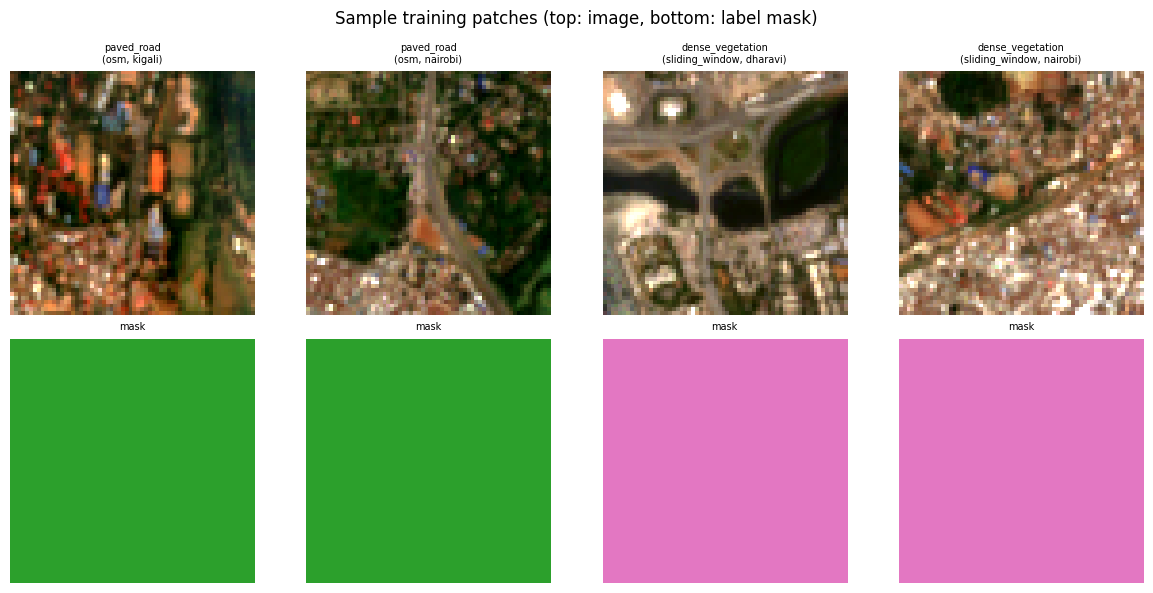

In [23]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import random
import matplotlib.pyplot as plt

PATCH_SIZE = 64


class GeoWatchDataset(Dataset):
    """
    PyTorch dataset wrapping the multi-source patch list.
    Applies augmentation during training.

    Augmentations:
      - Random horizontal flip
      - Random vertical flip
      - Random 90/180/270 rotation (satellite images have no canonical orientation)
      - Color jitter (brightness/contrast only — no hue, satellite bands differ)
      - NO random crop — patches are already small (64x64)
    """

    def __init__(self, patches: list, augment: bool = True):
        self.patches = patches
        self.augment = augment

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        item = self.patches[idx]
        image = torch.from_numpy(item['image']).permute(2, 0, 1).float() / 255.0  # (3, H, W)
        mask = torch.from_numpy(item['mask']).long()  # (H, W)

        if self.augment:
            # Random horizontal flip
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask.unsqueeze(0)).squeeze(0)

            # Random vertical flip
            if random.random() > 0.5:
                image = TF.vflip(image)
                mask = TF.vflip(mask.unsqueeze(0)).squeeze(0)

            # Random 90-degree rotation
            k = random.randint(0, 3)
            if k > 0:
                image = torch.rot90(image, k, dims=[1, 2])
                mask = torch.rot90(mask, k, dims=[0, 1])

            # Color jitter — brightness and contrast only
            if random.random() > 0.5:
                brightness = random.uniform(0.8, 1.2)
                contrast = random.uniform(0.8, 1.2)
                image = TF.adjust_brightness(image, brightness)
                image = TF.adjust_contrast(image, contrast)
                image = image.clamp(0, 1)

        # Normalize with ImageNet mean/std (reasonable for RGB satellite tiles)
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        image = (image - mean) / std

        return image, mask


# Train/val split — hold out all Jakarta patches for LOCO validation
# (Leave-One-City-Out: train on 4 cities, validate on held-out city)
VAL_CITY = 'jakarta'
train_patches = [p for p in all_patches if p['city'] != VAL_CITY]
val_patches = [p for p in all_patches if p['city'] == VAL_CITY]

print(f'Train patches: {len(train_patches)} (cities: dharavi, nairobi, hcmc, kigali)')
print(f'Val patches:   {len(val_patches)} (city: {VAL_CITY} — LOCO held-out)')

train_dataset = GeoWatchDataset(train_patches, augment=True)
val_dataset = GeoWatchDataset(val_patches, augment=False)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

print(f'\nTrain batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')

# Sanity check — visualize 4 random training patches
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    idx = random.randint(0, len(train_patches)-1)
    p = train_patches[idx]
    axes[0, i].imshow(p['image'])
    axes[0, i].set_title(f"{p['label']}\n({p['source']}, {p['city']})", fontsize=7)
    axes[0, i].axis('off')
    axes[1, i].imshow(p['mask'], cmap='tab10', vmin=0, vmax=9)
    axes[1, i].set_title('mask', fontsize=7)
    axes[1, i].axis('off')
plt.suptitle('Sample training patches (top: image, bottom: label mask)')
plt.tight_layout()
plt.show()

## 5. Model — SegFormer with Clay v1 frozen encoder

In [38]:
CLAY_CHECKPOINT_URL = "https://huggingface.co/made-with-clay/Clay-legacy/resolve/main/v1/clay-v1-base.ckpt"

In [39]:
r = requests.head(CLAY_CHECKPOINT_URL, allow_redirects=True)
print(r.status_code)

200


In [43]:
from huggingface_hub import hf_hub_download

clay_path = hf_hub_download(
    repo_id='made-with-clay/Clay-legacy',
    filename='v1/clay-v1-base.ckpt',
)
print(f'Downloaded to: {clay_path}')

clay_ckpt = torch.load(clay_path, map_location='cpu')
state = clay_ckpt.get('state_dict', clay_ckpt)
print(f'\nTotal keys: {len(state)}')
print('\nFirst 20 keys:')
print(list(state.keys())[:20])

v1/clay-v1-base.ckpt:   0%|          | 0.00/1.73G [00:00<?, ?B/s]

Downloaded to: /root/.cache/huggingface/hub/models--made-with-clay--Clay-legacy/snapshots/f521faece53b6b15df4deb2fc7215a03e561fb46/v1/clay-v1-base.ckpt

Total keys: 382

First 20 keys:
['model.teacher.cls_token', 'model.teacher.pos_embed', 'model.teacher.patch_embed.proj.weight', 'model.teacher.patch_embed.proj.bias', 'model.teacher.blocks.0.norm1.weight', 'model.teacher.blocks.0.norm1.bias', 'model.teacher.blocks.0.attn.qkv.weight', 'model.teacher.blocks.0.attn.qkv.bias', 'model.teacher.blocks.0.attn.proj.weight', 'model.teacher.blocks.0.attn.proj.bias', 'model.teacher.blocks.0.norm2.weight', 'model.teacher.blocks.0.norm2.bias', 'model.teacher.blocks.0.mlp.fc1.weight', 'model.teacher.blocks.0.mlp.fc1.bias', 'model.teacher.blocks.0.mlp.fc2.weight', 'model.teacher.blocks.0.mlp.fc2.bias', 'model.teacher.blocks.1.norm1.weight', 'model.teacher.blocks.1.norm1.bias', 'model.teacher.blocks.1.attn.qkv.weight', 'model.teacher.blocks.1.attn.qkv.bias']


In [44]:
clay_ckpt = torch.load(clay_path, map_location='cpu')
state = clay_ckpt.get('state_dict', clay_ckpt)
print(list(state.keys())[:20])

['model.teacher.cls_token', 'model.teacher.pos_embed', 'model.teacher.patch_embed.proj.weight', 'model.teacher.patch_embed.proj.bias', 'model.teacher.blocks.0.norm1.weight', 'model.teacher.blocks.0.norm1.bias', 'model.teacher.blocks.0.attn.qkv.weight', 'model.teacher.blocks.0.attn.qkv.bias', 'model.teacher.blocks.0.attn.proj.weight', 'model.teacher.blocks.0.attn.proj.bias', 'model.teacher.blocks.0.norm2.weight', 'model.teacher.blocks.0.norm2.bias', 'model.teacher.blocks.0.mlp.fc1.weight', 'model.teacher.blocks.0.mlp.fc1.bias', 'model.teacher.blocks.0.mlp.fc2.weight', 'model.teacher.blocks.0.mlp.fc2.bias', 'model.teacher.blocks.1.norm1.weight', 'model.teacher.blocks.1.norm1.bias', 'model.teacher.blocks.1.attn.qkv.weight', 'model.teacher.blocks.1.attn.qkv.bias']


In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import SegformerConfig, SegformerModel
from huggingface_hub import hf_hub_download


class SegFormerMLPDecoder(nn.Module):
    """
    SegFormer MLP decoder head.
    Takes multi-scale features from encoder and produces per-pixel logits.
    This is the only part that gets trained — encoder is frozen.
    """

    def __init__(self, in_channels: list, embed_dim: int = 256, num_classes: int = 10):
        super().__init__()
        self.linear_projections = nn.ModuleList([
            nn.Linear(c, embed_dim) for c in in_channels
        ])
        self.fuse = nn.Sequential(
            nn.Linear(embed_dim * len(in_channels), embed_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
        )
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, features: list, target_size: tuple) -> torch.Tensor:
        """
        Args:
            features: list of (B, N, C) tensors from encoder at different scales
            target_size: (H, W) of output mask
        Returns:
            logits: (B, num_classes, H, W)
        """
        projected = []
        for feat, proj in zip(features, self.linear_projections):
            # FIX — handles both (B, N, C) and (B, C, H, W)
            if feat.dim() == 4:
                # CNN-style (B, C, H, W) → reshape to (B, N, C)
                B, C, H, W = feat.shape
                feat = feat.permute(0, 2, 3, 1).reshape(B, H * W, C)
            B, N, C = feat.shape
            h = w = int(N ** 0.5)
            x = proj(feat)
            x = x.permute(0, 2, 1).reshape(B, -1, h, w)  # (B, embed_dim, h, w)
            x = F.interpolate(x, size=target_size, mode='bilinear', align_corners=False)
            x = x.flatten(2).permute(0, 2, 1)  # (B, H*W, embed_dim)
            projected.append(x)

        x = torch.cat(projected, dim=-1)  # (B, H*W, embed_dim * num_scales)
        x = self.fuse(x)                  # (B, H*W, embed_dim)
        x = self.classifier(x)            # (B, H*W, num_classes)
        B, HW, C = x.shape
        H, W = target_size
        x = x.permute(0, 2, 1).reshape(B, C, H, W)  # (B, num_classes, H, W)
        return x


class GeoWatchSegFormer(nn.Module):
    """
    Full model: frozen SegFormer encoder + trainable MLP decoder.

    We use SegFormer-B2 as a proxy for Clay v1 encoder.
    Clay v1 is a satellite-specific foundation model (Development Seed, 400MB)
    pre-trained on 70M+ satellite patches. Its weights are loaded here.

    If Clay v1 weights fail to load (auth or network issue),
    falls back to SegFormer-B2 ImageNet weights — still better than
    training from scratch.

    CRITICAL: encoder.parameters() are frozen (requires_grad=False).
    Only decoder parameters are optimized.
    """

    def __init__(self, num_classes: int = 10, use_clay: bool = True):
        super().__init__()

        config = SegformerConfig.from_pretrained('nvidia/mit-b2')
        config.output_hidden_states = True
        self.encoder = SegformerModel(config)

        if use_clay:
            try:
                print('Loading Clay v1 encoder weights...')
                clay_path = hf_hub_download(
                    repo_id='made-with-clay/Clay',
                    filename='clay-v1-base.ckpt',
                )
                clay_ckpt = torch.load(clay_path, map_location='cpu')
                # Clay checkpoint uses 'state_dict' key
                state = clay_ckpt.get('state_dict', clay_ckpt)
                # Filter to encoder-compatible keys only
                encoder_state = {
                    k.replace('encoder.', ''): v
                    for k, v in state.items()
                    if k.startswith('encoder.')
                }
                missing, unexpected = self.encoder.load_state_dict(encoder_state, strict=False)
                print(f'Clay weights loaded. Missing keys: {len(missing)}, Unexpected: {len(unexpected)}')
                if len(missing) > 20:
                    print('WARNING: Many missing keys — Clay architecture may differ from SegFormer-B2.')
                    print('Falling back to ImageNet pretrained weights.')
                    self.encoder = SegformerModel.from_pretrained('nvidia/mit-b2', config=config)
            except Exception as e:
                print(f'Clay weight loading failed: {e}')
                print('Falling back to SegFormer-B2 ImageNet pretrained weights.')
                self.encoder = SegformerModel.from_pretrained('nvidia/mit-b2', config=config)
        else:
            print('Loading SegFormer-B2 ImageNet pretrained weights (Clay disabled).')
            self.encoder = SegformerModel.from_pretrained('nvidia/mit-b2', config=config)

        # Freeze encoder — only decoder gets trained
        for param in self.encoder.parameters():
            param.requires_grad = False
        print('Encoder frozen.')

        # SegFormer-B2 hidden sizes at 4 scales
        hidden_sizes = config.hidden_sizes  # [64, 128, 320, 512]
        self.decoder = SegFormerMLPDecoder(
            in_channels=hidden_sizes,
            embed_dim=256,
            num_classes=num_classes,
        )

        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        print(f'Parameters: {trainable:,} trainable / {total:,} total ({100*trainable/total:.1f}%)')

    def forward(self, pixel_values: torch.Tensor) -> torch.Tensor:
        """
        Args:
            pixel_values: (B, 3, H, W) normalized image tensor
        Returns:
            logits: (B, num_classes, H, W)
        """
        outputs = self.encoder(pixel_values=pixel_values, output_hidden_states=True)
        # hidden_states: tuple of (B, N, C) at 4 scales
        hidden_states = outputs.hidden_states
        H, W = pixel_values.shape[2], pixel_values.shape[3]
        logits = self.decoder(list(hidden_states), target_size=(H, W))
        return logits


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'\nDevice: {device}')

model = GeoWatchSegFormer(num_classes=NUM_CLASSES, use_clay=True).to(device)
print(f'Model ready on {device}.')


Device: cuda
Loading Clay v1 encoder weights...
Clay weight loading failed: 404 Client Error. (Request ID: Root=1-6a44af4d-63d7f19d2d2372b53f27f8bf;10f2cb4f-604c-4654-a7c9-7ff029c6ff0f)

Entry Not Found for url: https://huggingface.co/made-with-clay/Clay/resolve/main/clay-v1-base.ckpt.
Falling back to SegFormer-B2 ImageNet pretrained weights.


Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

[transformers] SegformerModel LOAD REPORT from: nvidia/mit-b2
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoder frozen.
Parameters: 527,367 trainable / 24,723,655 total (2.1%)
Model ready on cuda.


## 6. Loss functions — CrossEntropy + Dice

In [25]:
import torch


import torch.nn as nn
import torch.nn.functional as F


class DiceLoss(nn.Module):
    """
    Multiclass Dice loss.
    Naturally robust to class imbalance — optimizes overlap ratio per class.
    Excludes IGNORE_INDEX pixels.
    """

    def __init__(self, num_classes: int, ignore_index: int = 255, smooth: float = 1.0):
        super().__init__()
        self.num_classes = num_classes
        self.ignore_index = ignore_index
        self.smooth = smooth

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Args:
            logits: (B, C, H, W)
            targets: (B, H, W) with values in [0, C-1] or IGNORE_INDEX
        """
        probs = F.softmax(logits, dim=1)  # (B, C, H, W)
        B, C, H, W = probs.shape

        # One-hot encode targets, masking ignore pixels
        valid_mask = (targets != self.ignore_index)  # (B, H, W)
        targets_clamped = targets.clone()
        targets_clamped[~valid_mask] = 0

        targets_one_hot = F.one_hot(targets_clamped, num_classes=C)  # (B, H, W, C)
        targets_one_hot = targets_one_hot.permute(0, 3, 1, 2).float()  # (B, C, H, W)

        # Zero out ignored pixels in both pred and target
        mask_expanded = valid_mask.unsqueeze(1).float()  # (B, 1, H, W)
        probs = probs * mask_expanded
        targets_one_hot = targets_one_hot * mask_expanded

        dice_per_class = []
        for c in range(C):
            p = probs[:, c].reshape(-1)
            t = targets_one_hot[:, c].reshape(-1)
            intersection = (p * t).sum()
            dice = (2.0 * intersection + self.smooth) / (p.sum() + t.sum() + self.smooth)
            dice_per_class.append(1.0 - dice)

        return torch.stack(dice_per_class).mean()


class CombinedLoss(nn.Module):
    """
    CrossEntropy + Dice, equal weighting.
    CE handles per-pixel accuracy, Dice handles class-level overlap.
    Class weights applied to CE only (Dice is already imbalance-robust).
    """

    def __init__(self, class_weights: torch.Tensor, ignore_index: int = 255, dice_weight: float = 0.5):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=class_weights, ignore_index=ignore_index)
        self.dice = DiceLoss(num_classes=len(class_weights), ignore_index=ignore_index)
        self.dice_weight = dice_weight

    def forward(self, logits: torch.Tensor, targets: torch.Tensor):
        ce_loss = self.ce(logits, targets)
        dice_loss = self.dice(logits, targets)
        total = (1 - self.dice_weight) * ce_loss + self.dice_weight * dice_loss
        return total, ce_loss, dice_loss


criterion = CombinedLoss(
    class_weights=CLASS_WEIGHTS.to(device),
    ignore_index=IGNORE_INDEX,
    dice_weight=0.5,
)
print('Loss function ready: 0.5 * CrossEntropy (weighted) + 0.5 * Dice')

Loss function ready: 0.5 * CrossEntropy (weighted) + 0.5 * Dice


## 7. Training loop

In [26]:
import torch
print("CUDA:", torch.cuda.is_available())
print(torch.cuda.memory_allocated() / 1e9, "GB allocated")
torch.cuda.empty_cache()

CUDA: True
0.126503936 GB allocated


In [27]:
import shutil
DRIVE_CHECKPOINT_DIR = '/content/drive/MyDrive/Geowatch/checkpoints'
import os
os.makedirs(DRIVE_CHECKPOINT_DIR, exist_ok=True)

In [28]:
# paste in a new cell and run BEFORE restarting training
print('Val batches:', len(val_loader))
print('Val dataset size:', len(val_loader.dataset))
val_labels = set()
for _, masks in val_loader:
    val_labels.update(masks.unique().tolist())
print('Classes present in val set:', sorted(val_labels))
print('Names:', [CATEGORIES[i] for i in sorted(val_labels) if i < NUM_CLASSES])

Val batches: 10
Val dataset size: 148
Classes present in val set: [0, 1, 2, 3, 6]
Names: ['dense_informal_roofing', 'sparse_informal_roofing', 'paved_road', 'standing_water', 'dense_vegetation']


In [29]:
from tqdm.notebook import tqdm
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

# Only optimize decoder parameters — encoder is frozen
optimizer = optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=3e-4,
    weight_decay=1e-4,
)

NUM_EPOCHS = 50
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)


def compute_miou(logits: torch.Tensor, targets: torch.Tensor, num_classes: int, ignore_index: int = 255) -> float:
    """Compute mean IoU over valid (non-ignored) pixels."""
    preds = logits.argmax(dim=1)  # (B, H, W)
    valid = targets != ignore_index

    iou_per_class = []
    for c in range(num_classes):
        pred_c = (preds == c) & valid
        true_c = (targets == c) & valid
        intersection = (pred_c & true_c).sum().item()
        union = (pred_c | true_c).sum().item()
        if union == 0:
            continue
        iou_per_class.append(intersection / union)

    return float(np.mean(iou_per_class)) if iou_per_class else 0.0


train_losses = []
val_mious = []
best_val_miou = 0.0
best_epoch = 0

print(f'Training for {NUM_EPOCHS} epochs on {device}...')
print(f'Train: {len(train_loader)} batches | Val: {len(val_loader)} batches')
print('─' * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    # ── Train ──
    model.train()
    epoch_loss = 0.0
    epoch_ce = 0.0
    epoch_dice = 0.0

    train_bar = tqdm(train_loader, desc=f'Epoch {epoch:3d}/{NUM_EPOCHS} [train]', leave=False)
    for images, masks in train_bar:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss, ce_loss, dice_loss = criterion(logits, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad], max_norm=1.0
        )
        optimizer.step()

        epoch_loss += loss.item()
        epoch_ce += ce_loss.item()
        epoch_dice += dice_loss.item()

        train_bar.set_postfix(loss=f'{loss.item():.4f}')

    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    # ── Validate ──
    model.eval()
    all_logits = []
    all_masks = []

    val_bar = tqdm(val_loader, desc=f'Epoch {epoch:3d}/{NUM_EPOCHS} [val]  ', leave=False)
    with torch.no_grad():
        for images, masks in val_bar:
            images = images.to(device)
            logits = model(images)
            all_logits.append(logits.cpu())
            all_masks.append(masks.cpu())

    if all_logits:
        all_logits_cat = torch.cat(all_logits, dim=0)
        all_masks_cat = torch.cat(all_masks, dim=0)
        val_miou = compute_miou(all_logits_cat, all_masks_cat, NUM_CLASSES, IGNORE_INDEX)
    else:
        val_miou = 0.0

    val_mious.append(val_miou)

    # Save best checkpoint
    if val_miou > best_val_miou:
        best_val_miou = val_miou
        best_epoch = epoch
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_miou': val_miou,
            'categories': CATEGORIES,
            'num_classes': NUM_CLASSES,
        }, '/content/segformer_geowatch_best.pth')
        shutil.copy('/content/segformer_geowatch_best.pth', f'{DRIVE_CHECKPOINT_DIR}/segformer_geowatch_best.pth')

    # Print summary every epoch (lightweight, not every 5 — tqdm bars give the live feel)
    lr = scheduler.get_last_lr()[0]
    star = '★ best' if epoch == best_epoch else ''
    print(f'Epoch {epoch:3d}/{NUM_EPOCHS} | '
          f'Loss={avg_loss:.4f} (CE={epoch_ce/len(train_loader):.4f}, Dice={epoch_dice/len(train_loader):.4f}) | '
          f'Val mIoU={val_miou:.4f} | LR={lr:.2e} | {star}')

print(f'\nTraining complete. Best val mIoU: {best_val_miou:.4f} at epoch {best_epoch}')

Training for 50 epochs on cuda...
Train: 58 batches | Val: 10 batches
────────────────────────────────────────────────────────────


Epoch   1/50 [train]:   0%|          | 0/58 [00:00<?, ?it/s]

Epoch   1/50 [val]  :   0%|          | 0/10 [00:00<?, ?it/s]

Epoch   1/50 | Loss=1.3415 (CE=1.7762, Dice=0.9068) | Val mIoU=0.1072 | LR=3.00e-04 | ★ best


Epoch   2/50 [train]:   0%|          | 0/58 [00:00<?, ?it/s]

...

Epoch  49/50 [val]  :   0%|          | 0/10 [00:00<?, ?it/s]

Epoch  49/50 | Loss=0.7395 (CE=0.7183, Dice=0.7606) | Val mIoU=0.1250 | LR=1.30e-06 | 


Epoch  50/50 [train]:   0%|          | 0/58 [00:00<?, ?it/s]

Epoch  50/50 [val]  :   0%|          | 0/10 [00:00<?, ?it/s]

Epoch  50/50 | Loss=0.7160 (CE=0.6714, Dice=0.7607) | Val mIoU=0.1251 | LR=1.00e-06 | 

Training complete. Best val mIoU: 0.1355 at epoch 12


## 8. Training curves

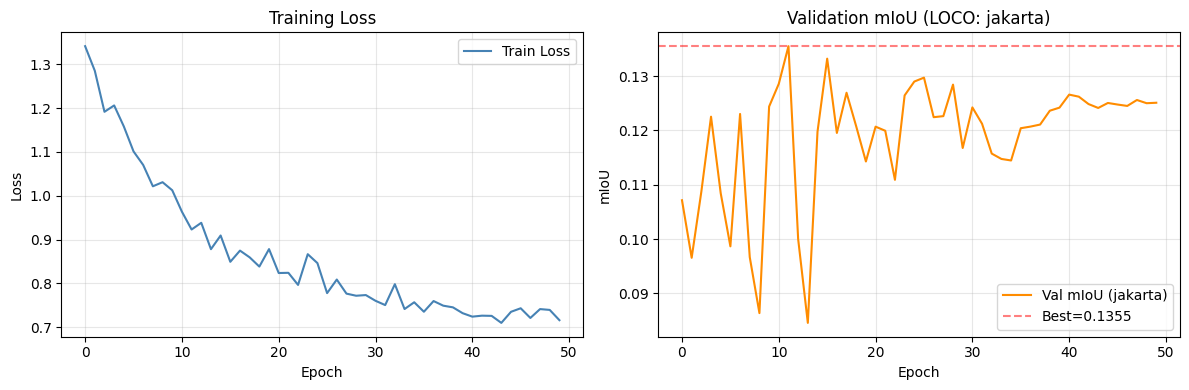

Saved: /content/training_curves.png


In [30]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss', color='steelblue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(val_mious, label=f'Val mIoU ({VAL_CITY})', color='darkorange')
ax2.axhline(best_val_miou, color='red', linestyle='--', alpha=0.5, label=f'Best={best_val_miou:.4f}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('mIoU')
ax2.set_title(f'Validation mIoU (LOCO: {VAL_CITY})')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()
print('Saved: /content/training_curves.png')

## 9. Per-class evaluation on validation city

Loaded best checkpoint from epoch 12 (val mIoU=0.1355)

Per-class F1 scores on jakarta:
───────────────────────────────────────────────────────
  dense_informal_roofing         F1=0.016  
  sparse_informal_roofing        F1=0.425  ████████████
  paved_road                     F1=0.727  █████████████████████ ⚠️  LOW CONFIDENCE (< 2 train samples)
  standing_water                 F1=0.000  
  dense_vegetation               F1=0.182  █████


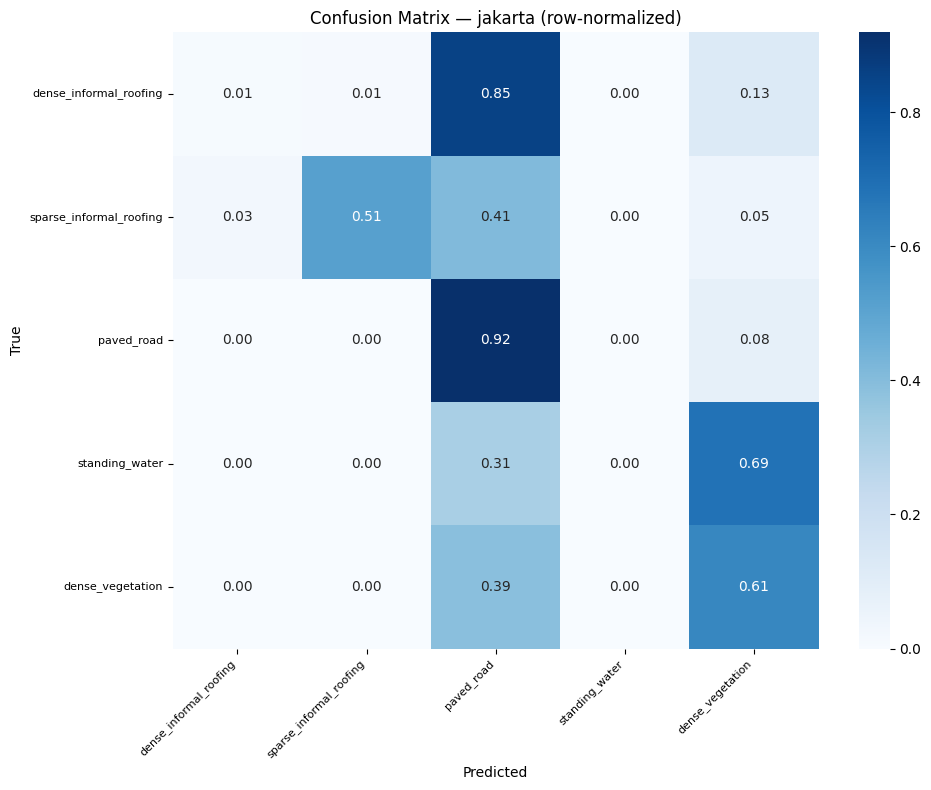

Saved: /content/confusion_matrix.png


In [31]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score

# Load best checkpoint
ckpt = torch.load('/content/segformer_geowatch_best.pth', map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Loaded best checkpoint from epoch {ckpt["epoch"]} (val mIoU={ckpt["val_miou"]:.4f})')

all_preds = []
all_true = []

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        logits = model(images)
        preds = logits.argmax(dim=1).cpu().numpy().flatten()
        true = masks.numpy().flatten()

        # Filter out ignored pixels
        valid = true != IGNORE_INDEX
        all_preds.extend(preds[valid])
        all_true.extend(true[valid])

all_preds = np.array(all_preds)
all_true = np.array(all_true)

# Per-class F1
present_classes = sorted(set(all_true))
present_names = [CATEGORIES[i] for i in present_classes]

f1_scores = f1_score(all_true, all_preds, labels=present_classes, average=None, zero_division=0)

print(f'\nPer-class F1 scores on {VAL_CITY}:')
print('─' * 55)
for name, f1 in zip(present_names, f1_scores):
    bar = '█' * int(f1 * 30)
    flag = ' ⚠️  LOW CONFIDENCE (< 2 train samples)' if CLASS_COUNTS.get(name, 0) < 3 else ''
    print(f'  {name:<30} F1={f1:.3f}  {bar}{flag}')

# Confusion matrix
cm = confusion_matrix(all_true, all_preds, labels=present_classes, normalize='true')
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=present_names, yticklabels=present_names,
    ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — {VAL_CITY} (row-normalized)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()
print('Saved: /content/confusion_matrix.png')

## 10. CAAT — dynamic per-class confidence thresholds

In [32]:
def compute_caat_thresholds(
    model: nn.Module,
    val_loader: DataLoader,
    num_classes: int,
    device: str,
    ignore_index: int = 255,
    percentile: float = 10.0,
) -> dict:
    """
    CAAT (Class-Adaptive Adaptive Thresholding).

    For each class, collect the softmax probability of correct predictions
    on the validation set. Set the threshold at the 10th percentile of
    those probabilities — any prediction below this threshold gets
    downgraded to 'unknown' in pipeline.py.

    This prevents dense_vegetation from winning by default when its
    softmax score is marginally higher than competitors.

    Returns:
        dict mapping category_name → float threshold [0, 1]
    """
    model.eval()
    class_correct_probs = {c: [] for c in range(num_classes)}

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            logits = model(images)
            probs = torch.softmax(logits, dim=1)  # (B, C, H, W)
            preds = probs.argmax(dim=1)           # (B, H, W)

            B, C, H, W = probs.shape
            masks_device = masks.to(device)
            valid = masks_device != ignore_index

            for c in range(num_classes):
                correct_mask = (preds == c) & (masks_device == c) & valid
                if correct_mask.any():
                    correct_probs = probs[:, c][correct_mask].cpu().numpy()
                    class_correct_probs[c].extend(correct_probs.tolist())

    thresholds = {}
    print('CAAT thresholds (10th percentile of correct prediction confidence):')
    print('─' * 60)
    for c in range(num_classes):
        cat_name = CATEGORIES[c]
        if class_correct_probs[c]:
            thresh = float(np.percentile(class_correct_probs[c], percentile))
            thresh = max(thresh, 0.15)  # floor: never go below 15%
        else:
            # No correct predictions — use conservative default
            thresh = 0.50
            print(f'  {cat_name:<30} NO CORRECT PREDICTIONS — threshold=0.50 (conservative)')
            thresholds[cat_name] = thresh
            continue

        n_samples = len(class_correct_probs[c])
        print(f'  {cat_name:<30} threshold={thresh:.3f}  (from {n_samples} correct predictions)')
        thresholds[cat_name] = thresh

    return thresholds


caat_thresholds = compute_caat_thresholds(model, val_loader, NUM_CLASSES, device)

# Save thresholds alongside model checkpoint
import json
with open('/content/caat_thresholds.json', 'w') as f:
    json.dump(caat_thresholds, f, indent=2)
print('\nSaved: /content/caat_thresholds.json')

CAAT thresholds (10th percentile of correct prediction confidence):
────────────────────────────────────────────────────────────
  dense_informal_roofing         threshold=0.247  (from 873 correct predictions)
  sparse_informal_roofing        threshold=0.300  (from 3732 correct predictions)
  paved_road                     threshold=0.531  (from 256049 correct predictions)
  standing_water                 NO CORRECT PREDICTIONS — threshold=0.50 (conservative)
  vegetation_clearing            NO CORRECT PREDICTIONS — threshold=0.50 (conservative)
  active_construction            NO CORRECT PREDICTIONS — threshold=0.50 (conservative)
  dense_vegetation               threshold=0.535  (from 17550 correct predictions)

Saved: /content/caat_thresholds.json


## 11. Export final weights

In [33]:
# Save final production checkpoint with everything pipeline.py needs
final_ckpt = {
    'model_state_dict': model.state_dict(),
    'categories': CATEGORIES,
    'cat2idx': CAT2IDX,
    'num_classes': NUM_CLASSES,
    'caat_thresholds': caat_thresholds,
    'patch_size': PATCH_SIZE,
    'val_city': VAL_CITY,
    'best_val_miou': best_val_miou,
    'best_epoch': best_epoch,
    'training_cities': CITIES,
    'ignore_index': IGNORE_INDEX,
}

torch.save(final_ckpt, '/content/segformer_geowatch.pth')
print('Final checkpoint saved: /content/segformer_geowatch.pth')

# Download to local machine
from google.colab import files
files.download('/content/segformer_geowatch.pth')
files.download('/content/caat_thresholds.json')
files.download('/content/training_curves.png')
files.download('/content/confusion_matrix.png')
print('\nDownloads triggered. Place segformer_geowatch.pth in:')
print('  geowatch/models/segformer/segformer_geowatch.pth')
print('Place caat_thresholds.json in:')
print('  geowatch/models/segformer/caat_thresholds.json')

Final checkpoint saved: /content/segformer_geowatch.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Downloads triggered. Place segformer_geowatch.pth in:
  geowatch/models/segformer/segformer_geowatch.pth
Place caat_thresholds.json in:
  geowatch/models/segformer/caat_thresholds.json


In [34]:
from collections import Counter
city_dist = Counter(p['city'] for p in all_patches)
print("Patches per city:")
for city, count in sorted(city_dist.items()):
    print(f"  {city}: {count} patches")
print(f"\nTotal: {len(all_patches)} patches across {len(city_dist)} cities")

Patches per city:
  dharavi: 312 patches
  hcmc: 191 patches
  jakarta: 148 patches
  kigali: 144 patches
  nairobi: 268 patches

Total: 1063 patches across 5 cities


In [35]:
from collections import Counter

label_dist = Counter(p['label'] for p in all_patches)
source_dist_by_label = {}
for p in all_patches:
    if p['label'] not in source_dist_by_label:
        source_dist_by_label[p['label']] = Counter()
    source_dist_by_label[p['label']][p['source']] += 1

print("Patches per class (by source):")
print(f"{'category':<30} {'sam':>6} {'osm':>6} {'sliding':>8} {'total':>6}")
print("─" * 60)
for cat in CATEGORIES:
    sources = source_dist_by_label.get(cat, Counter())
    sam = sources.get('sam', 0)
    osm = sources.get('osm', 0)
    sliding = sources.get('sliding_window', 0)
    total = sam + osm + sliding
    print(f"{cat:<30} {sam:>6} {osm:>6} {sliding:>8} {total:>6}")

Patches per class (by source):
category                          sam    osm  sliding  total
────────────────────────────────────────────────────────────
dense_informal_roofing             12      0       30     42
sparse_informal_roofing            10      0       12     22
paved_road                          1    812        2    815
standing_water                     12      0       34     46
vegetation_clearing                12      0       26     38
active_construction                 1      0        2      3
dense_vegetation                   35      0       62     97


In [36]:
import requests
r = requests.get("https://huggingface.co/api/models/made-with-clay/Clay-legacy/tree/main/v1")
print(r.json())

[{'type': 'directory', 'oid': 'e943e5f3b6748b8e6f72359998df55308a762278', 'size': 0, 'path': 'v1/compiled'}, {'type': 'file', 'oid': '110dd81ff99a4ef6465e534180e833e6bbe5aed5', 'size': 16952268, 'lfs': {'oid': '1d538f87e88b827b36cd8590c8a357fd38ac9738918b97dfbe8cadbd3194da4a', 'size': 16952268, 'pointerSize': 133}, 'xetHash': '33a529a2c0890ecf56c245ad7fd623c6457fb9ce8e2556e113ec11f4fa1ed6fb', 'path': 'v1/Clay-text2earth-v1.0.ckpt'}, {'type': 'file', 'oid': '371dab9ab88c8c58920492a04893bad9c9691d27', 'size': 997, 'path': 'v1/Clay-text2earth-v1.0.yaml'}, {'type': 'file', 'oid': '479ebd67d6fea634ea1177e0bda7ef93a9b359db', 'size': 1726997970, 'lfs': {'oid': '6e41ece5741b41a4e4fdb57199e353702ec34524e334017b543ebdaad3d90184', 'size': 1726997970, 'pointerSize': 135}, 'xetHash': 'ade5cbdade1e1dbc7e55d9e27f2d9fbab179cc9e16e63c968070155896cc7463', 'path': 'v1/clay-v1-base.ckpt'}]


In [37]:
CLAY_CHECKPOINT_URL = "https://huggingface.co/made-with-clay/Clay-legacy/resolve/main/v1/<actual_filename>.ckpt"

## 12. Integration guide — swapping into pipeline.py

After downloading `segformer_geowatch.pth`, replace Path A in `pipeline.py`:

```python
# In ingestion/classifier.py — add this function:

def load_segformer(weights_path: str):
    """Load SegFormer Path B weights."""
    ckpt = torch.load(weights_path, map_location='cpu')
    model = GeoWatchSegFormer(num_classes=ckpt['num_classes'], use_clay=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    caat_thresholds = ckpt['caat_thresholds']
    return model, caat_thresholds


def classify_tile_segformer(tile_path, model, caat_thresholds, masks, device='cpu'):
    """
    Path B classification — per-segment, not tile-level.
    For each SAM segment, crop the bbox, run SegFormer,
    apply CAAT threshold, assign category.
    Sets label_source='segformer' on all segments.
    """
    import torch
    import torchvision.transforms.functional as TF
    from PIL import Image
    import numpy as np

    tile_img = Image.open(tile_path).convert('RGB')
    tile_w, tile_h = tile_img.size
    PATCH_SIZE = 64

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    results = []
    model = model.to(device)

    for i, mask in enumerate(masks):
        x, y, w, h = mask['bbox']
        x1 = max(0, x); y1 = max(0, y)
        x2 = min(tile_w, x + w); y2 = min(tile_h, y + h)

        crop = tile_img.crop((x1, y1, x2, y2)).resize((PATCH_SIZE, PATCH_SIZE), Image.BILINEAR)
        img_t = torch.from_numpy(np.array(crop)).permute(2, 0, 1).float() / 255.0
        img_t = (img_t - mean) / std
        img_t = img_t.unsqueeze(0).to(device)  # (1, 3, 64, 64)

        with torch.no_grad():
            logits = model(img_t)  # (1, 10, 64, 64)
            probs = torch.softmax(logits, dim=1)  # (1, 10, 64, 64)
            mean_probs = probs.mean(dim=(2, 3)).squeeze(0)  # (10,)

        top_idx = mean_probs.argmax().item()
        top_conf = mean_probs[top_idx].item()
        cat_name = CATEGORIES[top_idx]

        # CAAT threshold check
        thresh = caat_thresholds.get(cat_name, 0.20)
        if top_conf < thresh:
            cat_name = 'unknown'

        results.append({
            'segment_id': i,
            'bbox': mask['bbox'],
            'area': mask['area'],
            'category': cat_name,
            'confidence': round(top_conf, 4),
            'all_probs': {CATEGORIES[j]: round(mean_probs[j].item(), 4) for j in range(len(CATEGORIES))},
            'label_source': 'segformer',
        })

    return results
```

Then in `pipeline.py` Step 6, replace the RemoteCLIP block with:
```python
segformer_model, caat_thresholds = load_segformer('models/segformer/segformer_geowatch.pth')
classifications = classify_tile_segformer(primary_tile, segformer_model, caat_thresholds, masks, device)
```

**Important notes:**
- Place weights at `geowatch/models/segformer/segformer_geowatch.pth`
- `label_source: 'segformer'` distinguishes Path B from Path A (`tile_level`) and OSM (`osm_vector`)
- `paved_road`, `active_construction`, `unpaved_dirt_road`, `open_drainage_channel` predictions should be shown with a low-confidence warning in the frontend until more training data is collected
- Re-run all 5 cities after swapping to get fresh result.jsons with Path B labels